# Módulo: Inteligencia de Negocios

## Tarea 1: Configuración de base de datos sources y entorno para ETL en Python

## Dominio: Salud

## Realizado por:
- Cristian Gonzalez
- Oscar Amagua
- Rafael Espinosa

## Grupo
Nro. 4

La idea principal de esta práctica es que sean obtenidas las fuentes de datos y configurar el entorno de desarrollo, los cuales serán el eje fundamental para el proyecto ETL.

![Diseño DB Covid.jpeg](Dise%C3%B1o%20BD/Dise%C3%B1o%20DB%20Covid.jpeg)

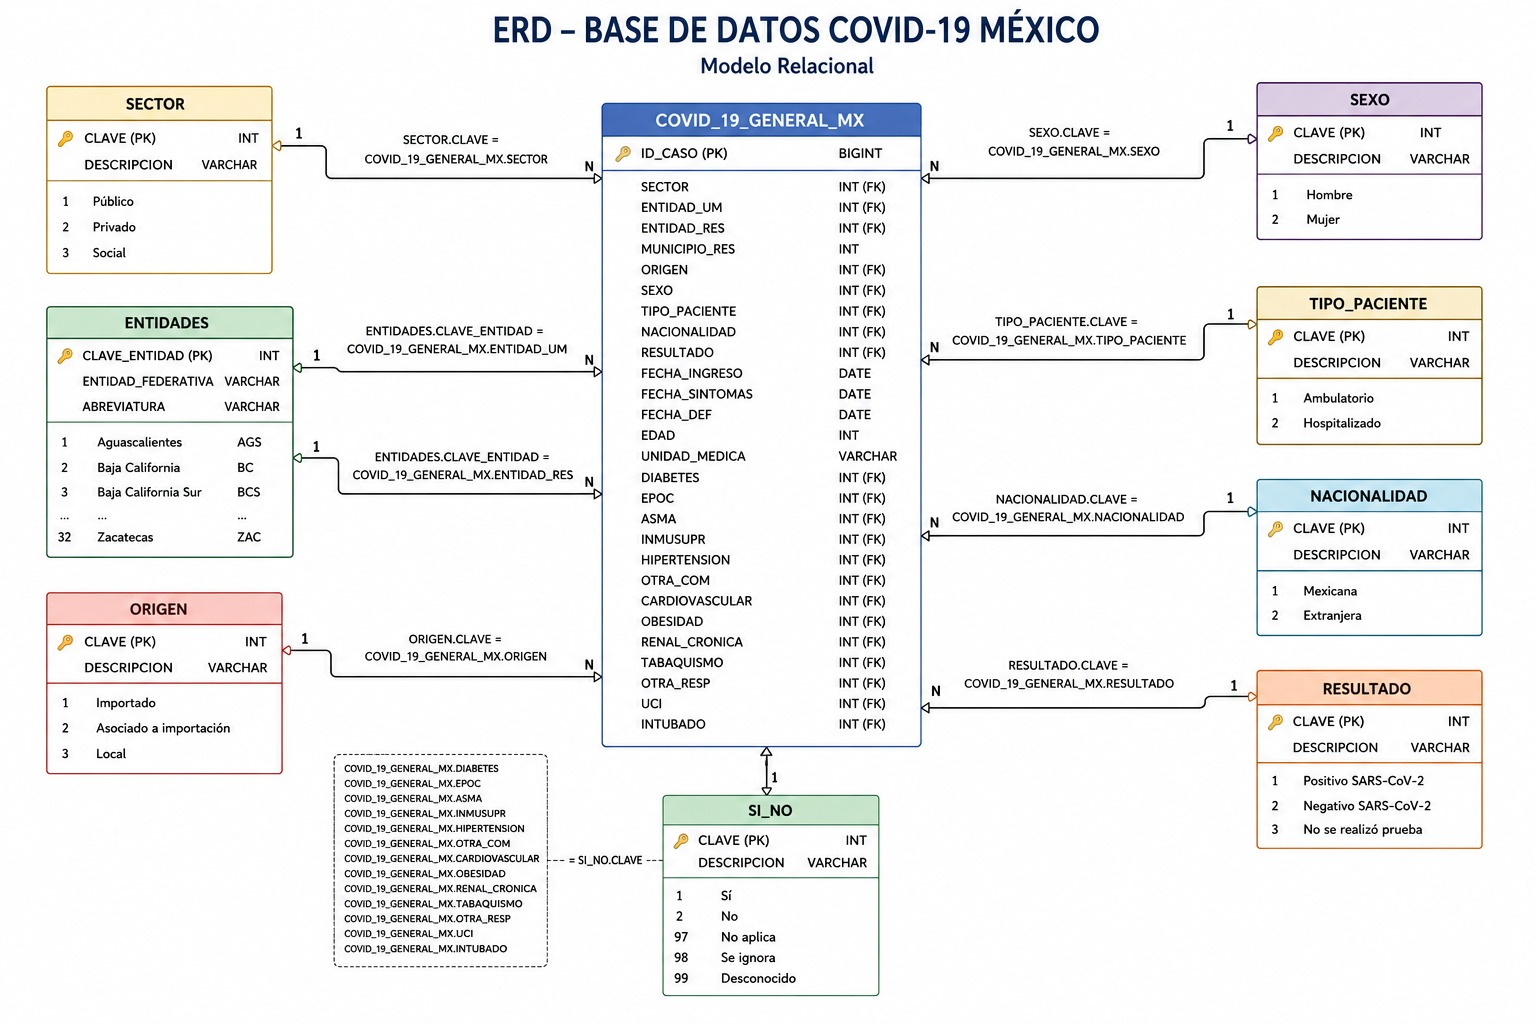

## Introducción:
Este proyecto está enfocado en el análisis de los datos relacionados con la enfermedad de COVID-19 en México. Su propósito principal es comprender el proceso de diseño y construcción de un modelo dimensional en esquema estrella (Star Schema), utilizado ampliamente en soluciones de inteligencia de negocios (Business Intelligence) y analítica de datos.

A partir de un conjunto de datos públicos, se desarrollará un proceso de integración, transformación y almacenamiento de la información en una base de datos orientada al análisis. Posteriormente, se diseñará un modelo analítico que facilite la consulta eficiente de grandes volúmenes de datos y permita obtener información relevante para la toma de decisiones.

Como parte del proyecto, se identificarán las tablas de dimensiones y la tabla de hechos, estableciendo las relaciones necesarias para representar la información de manera estructurada y optimizada. Además, se implementarán procesos de carga de datos (ETL), con el fin de garantizar la consistencia y calidad de la información.

Finalmente, el modelo desarrollado servirá como base para la generación de consultas, indicadores, reportes y visualizaciones que permitan analizar el comportamiento de la pandemia en México desde diferentes perspectivas, como la distribución geográfica de los casos, las características demográficas de los pacientes, los resultados de laboratorio, las instituciones de salud involucradas y otros factores de interés. De esta manera, el proyecto busca proporcionar una visión práctica sobre el diseño de almacenes de datos (Data Warehouse) y la aplicación de modelos analíticos para la explotación eficiente de la información.

## Importación de Dependencias


In [1]:
import os

import pandas as pd
from dotenv import load_dotenv
load_dotenv()
from sqlalchemy import create_engine

## Fase de Extracción de datos

En esta fase vamos a extraer los datos de nuestros sources

- Base de Datos ----> Entidades, Nacionalidad, Origen, Resultado --> Información de tablas
- Información en formato json ----> Sector --> Fuente de datos de sectores
- Información eb Formato CSV ----> covid-19_general_MX --> Información correspondiente a las fechas de ingreso de los pacientes, asociada a las diferentes afectaciones y manifestaciones sintomáticas registradas durante la atención médica.

### Manejo de Variables de Entorno

In [2]:
DB_USER= os.getenv("POSTGRES_USER")
DB_PASSWORD= os.getenv("POSTGRES_PASSWORD")
DB_NAME= os.getenv("POSTGRES_DB")
DB_HOST= os.getenv("POSTGRES_HOST")

## Cargando nuestra Base de Datos

In [3]:
engine = create_engine(f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}')


In [4]:
df_entidades = pd.read_sql('select * from cat_entidad_federativa', engine)

In [5]:
df_nacionalidad = pd.read_sql('select * from cat_nacionalidad', engine)

In [6]:
df_origen = pd.read_sql('select * from cat_tipo_usmer', engine)

In [7]:
df_resultado = pd.read_sql('select * from cat_resultado_laboratorio', engine)

In [8]:
df_sexo = pd.read_sql('select * from cat_sexo', engine)

In [9]:
df_respuesta = pd.read_sql('select * from cat_respuesta_binaria', engine)

## Carga de Datos Tipo Json

In [10]:
df_sector = pd.read_json("data/5 Sector.json")

In [11]:
df_tipopaciente = pd.read_json('data/5 Sector.json')

In [12]:
df_entidades

,clave_entidad,entidad_federativa,abreviatura
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL
5,6,COLIMA,CM
6,7,CHIAPAS,CS
7,8,CHIHUAHUA,CH
8,9,CIUDAD DE MÉXICO,DF
9,10,DURANGO,DG


In [13]:
df_sector

,clave,descripcion
0,1,CRUZ ROJA
1,2,DIF
2,3,ESTATAL
3,4,IMSS
4,5,IMSS-BIENESTAR
5,6,ISSSTE
6,7,MUNICIPAL
7,8,PEMEX
8,9,PRIVADA
9,10,SEDENA


## Carga de Datos tipo CSV

In [14]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")

In [15]:
df_covidgeneral

,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,...,INMUSUPR,HIPERTENSION,OTRA_CON,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,UCI
0,0,4,9,2,9,1,2020-03-23,2020-03-22,9999-99-99,97,...,2,2,2,2,2,2,2,99,1,97
1,1,4,9,2,9,2,2020-04-13,2020-04-04,9999-99-99,2,...,2,2,2,2,1,2,2,99,1,2
2,2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,...,2,1,2,2,1,2,2,99,1,2
3,3,4,30,1,30,1,2020-04-27,2020-04-17,9999-99-99,97,...,2,2,1,2,2,2,2,99,1,97
4,4,3,15,2,15,2,2020-06-06,2020-06-01,9999-99-99,2,...,2,2,2,2,2,2,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879603,879603,12,19,2,19,1,2020-07-02,2020-07-01,9999-99-99,97,...,2,2,2,2,2,2,2,1,3,97
879604,879604,3,26,2,26,2,2020-07-09,2020-07-02,9999-99-99,2,...,2,2,2,2,1,2,1,1,3,2
879605,879605,12,24,1,24,1,2020-07-16,2020-07-09,9999-99-99,97,...,2,2,2,1,2,2,2,2,3,97
879606,879606,12,9,1,9,1,2020-07-16,2020-07-11,9999-99-99,97,...,2,2,2,2,2,2,2,2,3,97


In [16]:
df_casosconfirmados = pd.read_csv('data/9 casos_confirmados.csv')

In [17]:
df_casosconfirmados

,Unnamed: 0,State,Sex,Age,Date,Confirmed
0,0,distrito federal,MASCULINO,28,2020-03-23,1
1,1,distrito federal,MASCULINO,49,2020-04-13,1
2,2,chihuahua,FEMENINO,67,2020-04-15,1
3,3,veracruz de ignacio de la llave,FEMENINO,41,2020-04-27,1
4,4,méxico,MASCULINO,43,2020-06-06,1
...,...,...,...,...,...,...
370707,724196,sinaloa,MASCULINO,77,2020-07-16,1
370708,724197,nuevo león,MASCULINO,79,2020-07-17,1
370709,724198,guanajuato,MASCULINO,35,2020-07-17,1
370710,724199,méxico,MASCULINO,36,2020-07-17,1


## Análisis de Cada DataFrame

El objetivo de este análisis es identificar y comprender las relaciones existentes entre las diferentes fuentes de datos que conforman el conjunto de información del proyecto. Esta etapa constituye el punto de partida para el diseño del modelo dimensional, permitiendo establecer las entidades, atributos y relaciones que darán origen al esquema estrella (Star Schema).

Durante este proceso se busca conocer en profundidad la estructura, el significado y la calidad de los datos, con el fin de determinar cuáles aportan valor al análisis y cómo deben organizarse para responder a las necesidades del negocio. La correcta comprensión de la información permitirá definir la tabla de hechos y las tablas de dimensiones, optimizando el modelo para facilitar la generación de indicadores, consultas analíticas y reportes.

En consecuencia, esta fase representa un paso fundamental en la construcción del modelo analítico, ya que garantiza que la información almacenada en el almacén de datos (Data Warehouse) sea consistente, confiable y adecuada para apoyar la toma de decisiones basada en datos.

In [18]:
df_entidades

,clave_entidad,entidad_federativa,abreviatura
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL
5,6,COLIMA,CM
6,7,CHIAPAS,CS
7,8,CHIHUAHUA,CH
8,9,CIUDAD DE MÉXICO,DF
9,10,DURANGO,DG


In [19]:
df_sector

,clave,descripcion
0,1,CRUZ ROJA
1,2,DIF
2,3,ESTATAL
3,4,IMSS
4,5,IMSS-BIENESTAR
5,6,ISSSTE
6,7,MUNICIPAL
7,8,PEMEX
8,9,PRIVADA
9,10,SEDENA


In [20]:
df_covidgeneral

,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,...,INMUSUPR,HIPERTENSION,OTRA_CON,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,UCI
0,0,4,9,2,9,1,2020-03-23,2020-03-22,9999-99-99,97,...,2,2,2,2,2,2,2,99,1,97
1,1,4,9,2,9,2,2020-04-13,2020-04-04,9999-99-99,2,...,2,2,2,2,1,2,2,99,1,2
2,2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,...,2,1,2,2,1,2,2,99,1,2
3,3,4,30,1,30,1,2020-04-27,2020-04-17,9999-99-99,97,...,2,2,1,2,2,2,2,99,1,97
4,4,3,15,2,15,2,2020-06-06,2020-06-01,9999-99-99,2,...,2,2,2,2,2,2,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879603,879603,12,19,2,19,1,2020-07-02,2020-07-01,9999-99-99,97,...,2,2,2,2,2,2,2,1,3,97
879604,879604,3,26,2,26,2,2020-07-09,2020-07-02,9999-99-99,2,...,2,2,2,2,1,2,1,1,3,2
879605,879605,12,24,1,24,1,2020-07-16,2020-07-09,9999-99-99,97,...,2,2,2,1,2,2,2,2,3,97
879606,879606,12,9,1,9,1,2020-07-16,2020-07-11,9999-99-99,97,...,2,2,2,2,2,2,2,2,3,97


In [21]:
df_origen

,clave,descripcion
0,1,USMER
1,2,FUERA DE USMER
2,99,NO ESPECIFICADO


In [22]:
df_resultado

,clave,descripcion
0,1,Positivo SARS-CoV-2
1,2,No positivo SARS-CoV-2
2,3,Resultado pendiente


# Generar tres scripts de análisis de datos a cada uno de los Data Frames

Mostrar las 5 primeras filas de cada uno

## Base de Datos Postgres

In [29]:
df_entidades = pd.read_sql('select * from cat_entidad_federativa limit 5', engine)
df_entidades

,clave_entidad,entidad_federativa,abreviatura
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL


In [30]:
df_nacionalidad = pd.read_sql('select * from cat_nacionalidad limit 5', engine)
df_nacionalidad

,clave,descripcion
0,1,MEXICANA
1,2,EXTRANJERA
2,99,NO ESPECIFICADO


In [31]:
df_origen = pd.read_sql('select * from cat_tipo_usmer limit 5', engine)
df_origen

,clave,descripcion
0,1,USMER
1,2,FUERA DE USMER
2,99,NO ESPECIFICADO


In [32]:
df_resultado = pd.read_sql('select * from cat_resultado_laboratorio limit 5', engine)
df_resultado

,clave,descripcion
0,1,Positivo SARS-CoV-2
1,2,No positivo SARS-CoV-2
2,3,Resultado pendiente


In [33]:
df_sexo = pd.read_sql('select * from cat_sexo limit 5', engine)
df_sexo

,clave,descripcion
0,1,MUJER
1,2,HOMBRE
2,99,NO ESPECIFICADO


In [34]:
df_respuesta = pd.read_sql('select * from cat_respuesta_binaria limit 5', engine)
df_respuesta

,clave,descripcion
0,1,SI
1,2,NO
2,97,NO APLICA
3,98,SE IGNORA
4,99,NO ESPECIFICADO


## Datos Json


In [35]:
df_sector = pd.read_json("data/5 Sector.json")
df_sector.head(5)

,clave,descripcion
0,1,CRUZ ROJA
1,2,DIF
2,3,ESTATAL
3,4,IMSS
4,5,IMSS-BIENESTAR


In [37]:
df_tipopaciente = pd.read_json('data/5 Sector.json')
df_tipopaciente.head(5)

,clave,descripcion
0,1,CRUZ ROJA
1,2,DIF
2,3,ESTATAL
3,4,IMSS
4,5,IMSS-BIENESTAR


## Archivo de Datos CVS


In [38]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
df_covidgeneral.head(5)

,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,...,INMUSUPR,HIPERTENSION,OTRA_CON,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,UCI
0,0,4,9,2,9,1,2020-03-23,2020-03-22,9999-99-99,97,...,2,2,2,2,2,2,2,99,1,97
1,1,4,9,2,9,2,2020-04-13,2020-04-04,9999-99-99,2,...,2,2,2,2,1,2,2,99,1,2
2,2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,...,2,1,2,2,1,2,2,99,1,2
3,3,4,30,1,30,1,2020-04-27,2020-04-17,9999-99-99,97,...,2,2,1,2,2,2,2,99,1,97
4,4,3,15,2,15,2,2020-06-06,2020-06-01,9999-99-99,2,...,2,2,2,2,2,2,2,1,1,2


In [39]:
df_casosconfirmados = pd.read_csv('data/9 casos_confirmados.csv')
df_casosconfirmados.head(5)

,Unnamed: 0,State,Sex,Age,Date,Confirmed
0,0,distrito federal,MASCULINO,28,2020-03-23,1
1,1,distrito federal,MASCULINO,49,2020-04-13,1
2,2,chihuahua,FEMENINO,67,2020-04-15,1
3,3,veracruz de ignacio de la llave,FEMENINO,41,2020-04-27,1
4,4,méxico,MASCULINO,43,2020-06-06,1


## Identificar que columnas tienen nulos en los Data Frames


In [40]:
df_entidades = pd.read_sql('select * from cat_entidad_federativa', engine)
df_entidades.isnull().values.any()

np.False_

In [41]:
df_nacionalidad = pd.read_sql('select * from cat_nacionalidad', engine)
df_nacionalidad.isnull().values.any()


np.False_

In [42]:
df_origen = pd.read_sql('select * from cat_tipo_usmer', engine)
df_origen.isnull().values.any()

np.False_

In [43]:
df_resultado = pd.read_sql('select * from cat_resultado_laboratorio', engine)
df_resultado.isnull().values.any()

np.False_

In [44]:
df_sexo = pd.read_sql('select * from cat_sexo', engine)
df_sexo.isnull().values.any()

np.False_

In [46]:
df_respuesta = pd.read_sql('select * from cat_respuesta_binaria', engine)
df_respuesta.isnull().values.any()

np.False_

In [47]:
df_sector = pd.read_json("data/5 Sector.json")
df_sector.isnull().values.any()

np.False_

In [48]:
df_tipopaciente = pd.read_json('data/5 Sector.json')
df_tipopaciente.isnull().values.any()

np.False_

In [49]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
df_covidgeneral.isnull().values.any()

np.False_

In [50]:
df_casosconfirmados = pd.read_csv('data/9 casos_confirmados.csv')
df_casosconfirmados.isnull().values.any()

np.False_

## Contar cuantos valores faltan en cada columna


In [51]:
df_entidades = pd.read_sql('select * from cat_entidad_federativa', engine)
df_entidades.isnull().sum()

clave_entidad         0
entidad_federativa    0
abreviatura           0
dtype: int64

In [52]:
df_nacionalidad = pd.read_sql('select * from cat_nacionalidad', engine)
df_nacionalidad.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [53]:
df_origen = pd.read_sql('select * from cat_tipo_usmer', engine)
df_origen.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [54]:
df_resultado = pd.read_sql('select * from cat_resultado_laboratorio', engine)
df_resultado.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [56]:
df_sexo = pd.read_sql('select * from cat_sexo', engine)
df_sexo.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [57]:
df_respuesta = pd.read_sql('select * from cat_respuesta_binaria', engine)
df_respuesta.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [58]:
df_sector = pd.read_json("data/5 Sector.json")
df_sector.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [59]:
df_tipopaciente = pd.read_json('data/5 Sector.json')
df_tipopaciente.isnull().sum()

clave          0
descripcion    0
dtype: int64

In [60]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
df_covidgeneral.isnull().sum()

Unnamed: 0        0
SECTOR            0
ENTIDAD_UM        0
SEXO              0
ENTIDAD_RES       0
TIPO_PACIENTE     0
FECHA_INGRESO     0
FECHA_SINTOMAS    0
FECHA_DEF         0
INTUBADO          0
NEUMONIA          0
EDAD              0
NACIONALIDAD      0
DIABETES          0
EPOC              0
ASMA              0
INMUSUPR          0
HIPERTENSION      0
OTRA_CON          0
CARDIOVASCULAR    0
OBESIDAD          0
RENAL_CRONICA     0
TABAQUISMO        0
OTRO_CASO         0
RESULTADO         0
UCI               0
dtype: int64

In [61]:
df_casosconfirmados = pd.read_csv('data/9 casos_confirmados.csv')
df_casosconfirmados.isnull().sum()

Unnamed: 0    0
State         0
Sex           0
Age           0
Date          0
Confirmed     0
dtype: int64

## Calcular el promedio, máximo y mínimo de una variable numérica a su elección
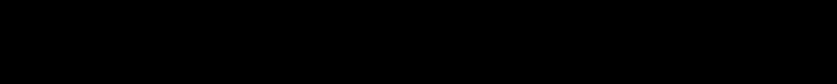

### Data frame df_covidgeneral

In [70]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
print(f"{df_covidgeneral["EDAD"].mean():.2f}")


42.55


In [67]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
print(df_covidgeneral["EDAD"].max())

120


In [68]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")
print(df_covidgeneral["EDAD"].min())

0


## Encontrar el valor máximo y mínimo de dos variables agrupadas

### Data Frame df_casosconfirmados

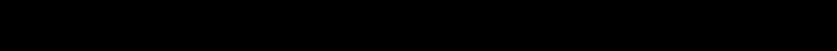

In [79]:
df_casosconfirmados.groupby("State").size()

State
aguascalientes                      3620
baja california                    12533
baja california sur                 3482
campeche                            3845
chiapas                             5547
chihuahua                           4635
coahuila                           10404
colima                              1316
distrito federal                   66444
durango                             3536
guanajuato                         16270
guerrero                            9576
hidalgo                             5898
jalisco                            11473
michoacán                           8600
morelos                             3764
méxico                             48592
nayarit                             3003
nuevo león                         13720
oaxaca                              9337
puebla                             17797
querétaro                           3155
quintana roo                        6560
san luis potosí                     6726
sinaloa   

In [78]:
df_casosconfirmados.groupby("State")["Age"].agg(["min", "max"])

,min,max
State,,
aguascalientes,0,99
baja california,0,99
baja california sur,0,100
campeche,1,100
chiapas,0,106
chihuahua,0,100
coahuila,0,95
colima,0,96
distrito federal,0,105


In [81]:
df_casosconfirmados.groupby("Sex")["Age"].agg(["min", "max", "mean"])

,min,max,mean
Sex,,,
FEMENINO,0,105,44.539639
MASCULINO,0,119,45.998044


# Actividad Individual: Aplicación de la práctica en el entorno profesional


## Rafael Espinosa

# Reflexión sobre la aplicación de los conocimientos adquiridos

El área profesional en la que me desempeño es la de Tecnologías de la Información (TI), específicamente en la gestión de sistemas, análisis de información y soporte a los procesos de negocio. A lo largo de mi trayectoria profesional he participado en proyectos relacionados con la administración de plataformas tecnológicas, integración de sistemas y análisis de datos para la toma de decisiones, por lo que los conocimientos adquiridos en esta práctica tienen una aplicación directa en mi entorno laboral.

En este ámbito se generan y gestionan grandes volúmenes de información provenientes de diferentes fuentes, como sistemas transaccionales, bases de datos corporativas, aplicaciones web, plataformas financieras, sistemas de atención al cliente y herramientas de monitoreo. Estos datos incluyen registros de usuarios, transacciones, indicadores operativos, métricas de desempeño, incidencias, información financiera y reportes de gestión, los cuales deben ser almacenados y procesados de manera eficiente para generar conocimiento útil para la organización.

Las herramientas estudiadas durante esta práctica permiten abordar estas necesidades de forma integral. PostgreSQL puede utilizarse como motor de base de datos para almacenar información estructurada de manera segura y confiable. Docker facilita la implementación y administración de entornos de desarrollo y producción mediante contenedores, garantizando la portabilidad y consistencia de las aplicaciones. Por su parte, Python ofrece un amplio conjunto de librerías para la automatización de procesos, integración de datos y análisis de información, permitiendo desarrollar procesos ETL capaces de extraer datos de diferentes fuentes, transformarlos según las necesidades del negocio y cargarlos en repositorios centralizados para su posterior explotación.

La implementación de procesos ETL aportaría importantes beneficios a la organización. Entre ellos destacan la automatización de tareas repetitivas, la reducción de errores manuales, la mejora en la calidad de los datos, la integración de información proveniente de múltiples sistemas y la disponibilidad de datos consolidados para la generación de reportes e indicadores. Además, permitiría contar con información actualizada y confiable para apoyar la toma de decisiones estratégicas y operativas.

Finalmente, el análisis de los datos obtenidos permitiría identificar tendencias, evaluar el desempeño de procesos, optimizar recursos, detectar oportunidades de mejora y anticipar posibles riesgos. De esta manera, las organizaciones podrían fundamentar sus decisiones en información objetiva y oportuna, incrementando su eficiencia operativa y su capacidad para responder a los desafíos del entorno empresarial actual.


## Oscar Amagua

# Reflexión sobre la aplicación de los conocimientos adquiridos

## Cristian Gonzalez

# Reflexión sobre la aplicación de los conocimientos adquiridos